In [1]:
import scvelo as scv
import scanpy as sc
import pandas as pd 
import numpy as np 
import os 
from pathlib import Path

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\mouse_gut'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
abs_path = str(Path(notebook_dir).parents[3])
os.chdir(abs_path)
os.getcwd()

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github'

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

In [7]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'real_data_2') 

In [8]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [ ]:
# for k, adata in adata_dict.items():
#     adata.var.set_index("gene_name",drop=True,inplace=True)


# Read Adatas with Velocity

In [11]:
adata = adata_dict['adata_gut_ep_deterministic']

In [12]:
adata

AnnData object with n_obs × n_vars = 16348 × 335
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'leiden', 'velocity_self_transition', 'cell_type'
    var: 'Ensemble ID', 'feature_types', 'genome', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'dendrogram_leiden', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap', 'spatial', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

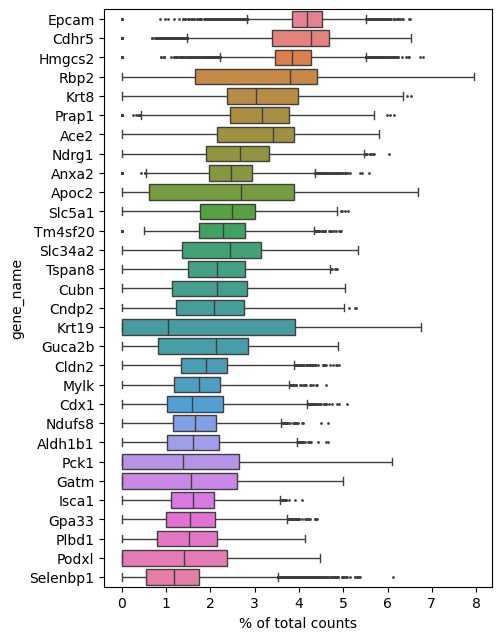

In [13]:
sc.pl.highest_expr_genes(adata, n_top=30)

# Velocity 

- 3 options for calculating velocity:
    - Deterministic 
    - Dynamic
    - Stochastic 

Information can be found [here](https://scvelo.readthedocs.io/en/stable/about.html).

In [14]:
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

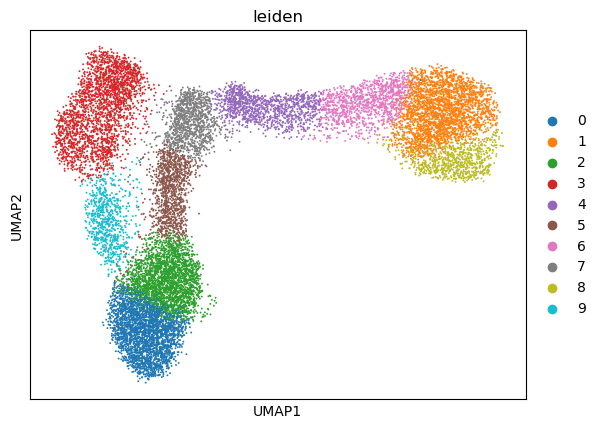

In [15]:
sc.pl.umap(adata,color='leiden')

## Deterministic Velocity

<Axes: >

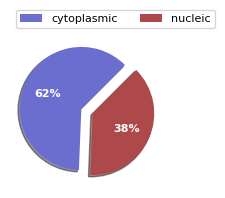

In [16]:
proportions_nuc_cyto(adata,fontsize=8)

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


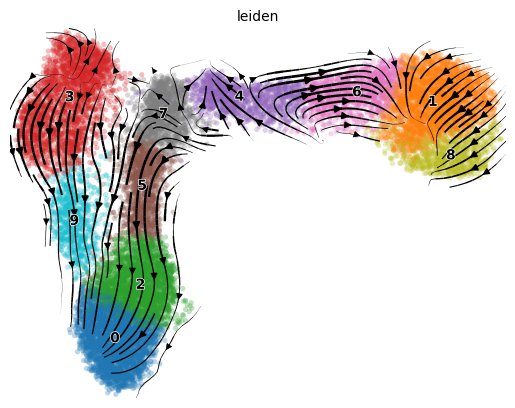

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


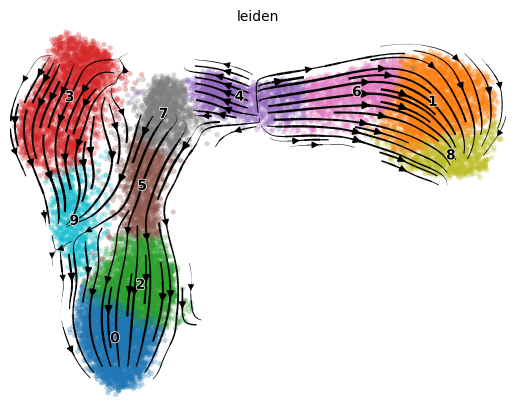

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


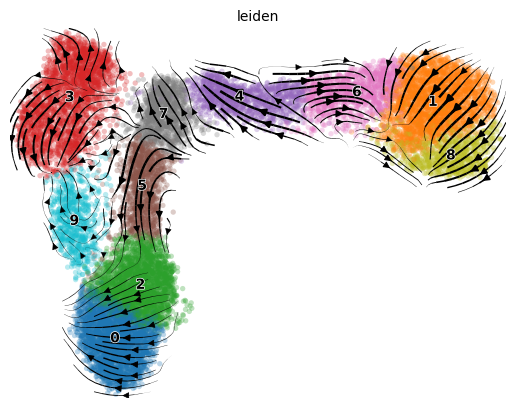

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


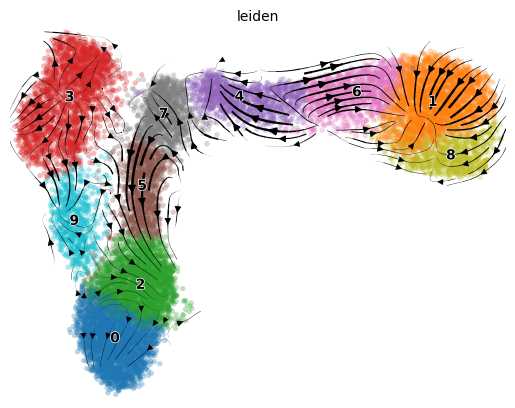

In [17]:
for k, adata in adata_dict.items():
    scv.pl.velocity_embedding_stream(adata, basis='umap', color='leiden')

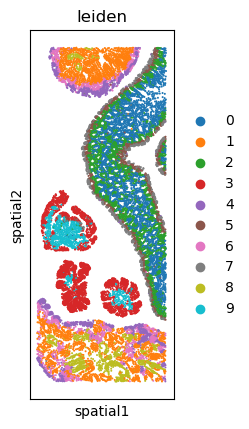

In [30]:
sc.pl.spatial(adata, color="leiden", spot_size = 20)

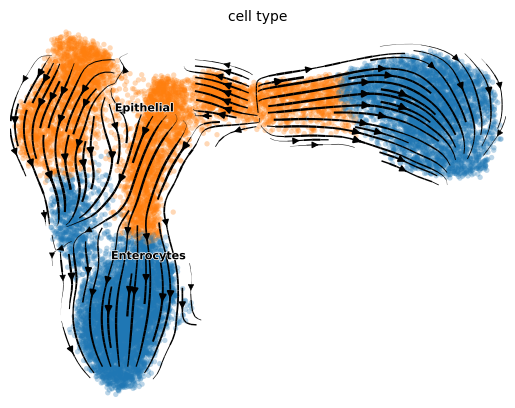

In [21]:
scv.pl.velocity_embedding_stream(adata_dict['adata_gut_ep_dynamical'], basis='umap', color='cell_type',legend_fontsize=8)

In [23]:
marker_dict = {}
for i in range(10):
    markers= list(sc.get.rank_genes_groups_df(adata,group=str(i))['names'].head(5))
    marker_dict[i] = markers

In [24]:
marker_dict

{0: ['Slc34a2', 'Ace2', 'Cndp2', 'Cdhr5', 'Guca2b'],
 1: ['Apoc2', 'Pck1', 'Prap1', 'Rbp2', 'Cdhr5'],
 2: ['Krt19', '2610528A11Rik', 'Krt8', 'Epcam', 'Hmgcs2'],
 3: ['Krt19', 'Krt8', 'Tspan8', 'Epcam', 'Ndrg1'],
 4: ['Myh11', 'Myl9', 'Tagln', 'Mylk', 'Cnn1'],
 5: ['Krt19', 'Krt8', 'Prap1', 'Hmgcs2', 'Cldn2'],
 6: ['Bgn', 'Cav1', 'Calcrl', 'Mfap4', 'Lum'],
 7: ['Bgn', 'Stmn1', 'Mfap4', 'Lum', 'Sfrp1'],
 8: ['Eng', 'Plvap', 'Cav1', 'Kdr', 'Tie1'],
 9: ['Ptn', 'Igfbp6', 'Upk3b', 'Cav1', 'Nbl1']}

In [25]:
sc.tl.rank_genes_groups(adata_dict["adata_gut_ep_deterministic"],groupby="leiden")

In [28]:
sc.tl.dendrogram(adata_dict['adata_gut_ep_deterministic'],groupby="leiden")

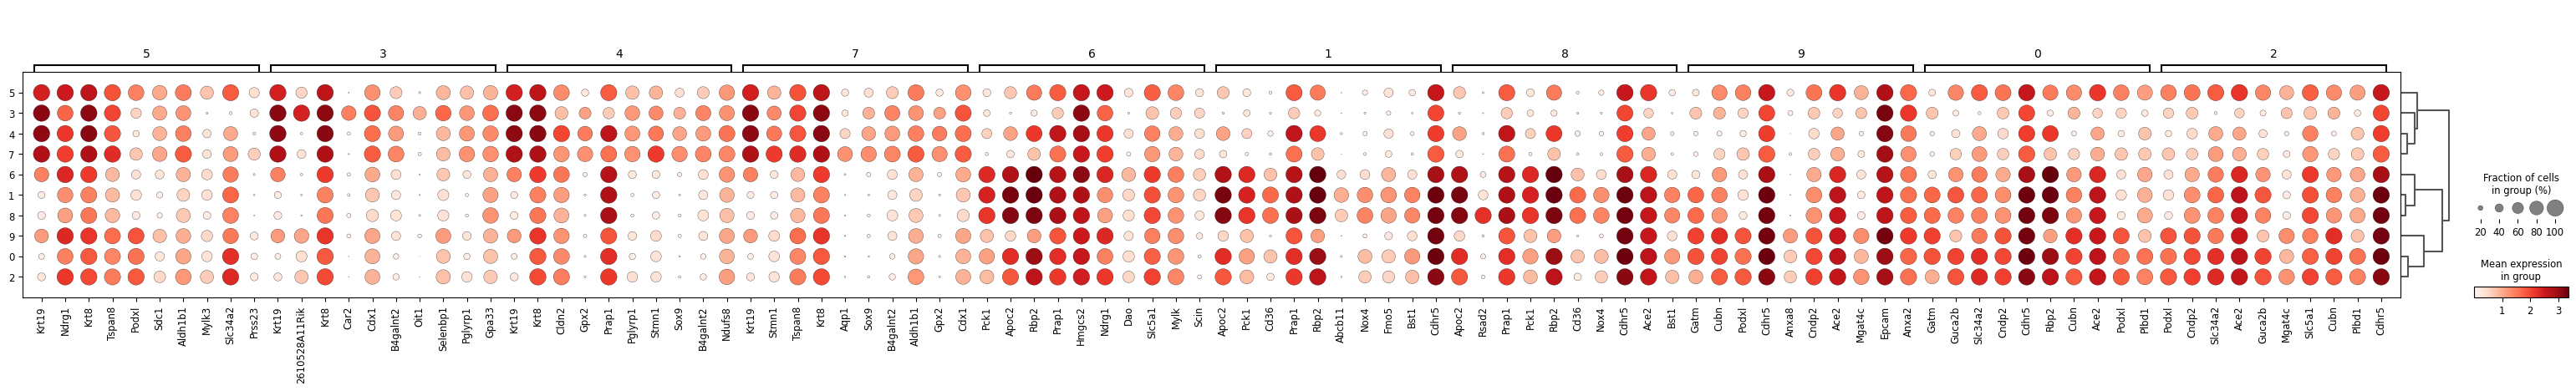

In [29]:
sc.pl.rank_genes_groups_dotplot(adata_dict["adata_gut_ep_deterministic"],groupby="leiden")

In [60]:
list(sc.get.rank_genes_groups_df(adata_dict["adata_gut_deterministic"],group="14")['names'].head(6))

['C3', 'Uox', 'Hp', 'Ambp', 'Kng2', 'Gc']

In [ ]:
cell_types ={  '0': "Absorptive Enterocytes",
    '1': "Metabolic Enterocytes",
    '2': "Epithelial Progenitor Cells",
    '3': "Epithelial Progenitor Cells",
    '4': "SMC",
    '5': "Epithelial Progenitor Cells",
    '6': "Fibroblasts",
    '7': "Fibroblasts",
    '8': "Endothelial",
    '9': "Mesothelial"}


In [ ]:
for k, adata in adata_dict.items():
    adata.obs['cell_types'] = adata.obs['leiden'].map(cell_types)

In [96]:
adata = adata_dict['adata_gut_deterministic']

In [97]:
adata_filtered = adata[adata.obs['cell_type'].isin(clusters_of_interest)]

In [98]:
adata_filtered

View of AnnData object with n_obs × n_vars = 16348 × 337
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'leiden', 'velocity_self_transition', 'cell_type'
    var: 'Ensemble ID', 'feature_types', 'genome', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'rank_genes_groups', 'dendrogram_leiden', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

In [105]:
adata_filtered.obs.cell_type

9287       Enterocytes
9289       Enterocytes
9290       Enterocytes
9291       Enterocytes
9292       Enterocytes
              ...     
1316171     Epithelial
1316173     Epithelial
1316174     Epithelial
1316175     Epithelial
1316176     Epithelial
Name: cell_type, Length: 16348, dtype: object

In [107]:
adata_filtered.write("data/Xenium_V1_mouse_pup_outs/adata_filtered_epithelial.h5ad")

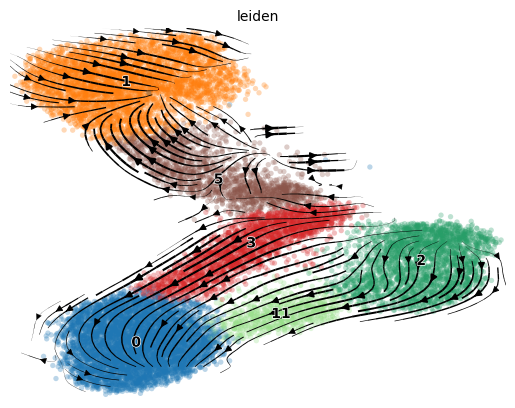

In [106]:
scv.pl.velocity_embedding_stream(adata_filtered,basis='umap',color='leiden')

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


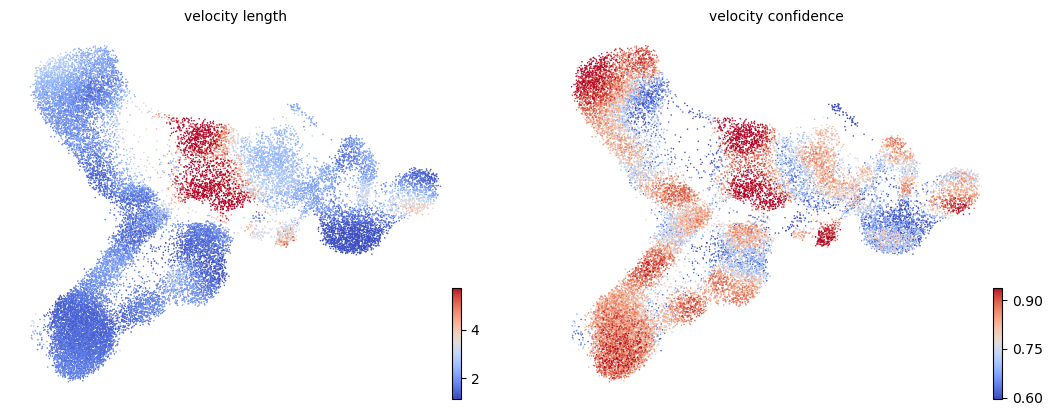

In [39]:
scv.tl.velocity_confidence(adata_dict['adata_gut_deterministic'])
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_dict['adata_gut_deterministic'], c=keys, cmap='coolwarm', perc=[5, 95])

In [40]:
df = adata_dict['adata_gut_deterministic'].obs.groupby('leiden')[["velocity_length","velocity_confidence"]].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

leiden,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
velocity_length,1.436470,1.966242,1.579027,1.758520,1.229336,1.701602,2.412656,5.518880,5.374129,2.113202,2.275973,1.600240,3.460189,2.376729,2.280454
velocity_confidence,0.833514,0.806960,0.761557,0.803230,0.653027,0.785971,0.772633,0.833255,0.862979,0.753392,0.806957,0.828607,0.819954,0.657357,0.499228


In [41]:
adata_dict['adata_gut_deterministic'].obs.reset_index(drop=True,inplace=True)

In [42]:
adata_dict['adata_gut_deterministic'].obs.reset_index(drop=False,inplace=True)

computing terminal states
    identified 8 regions of root cells and 2 regions of end points .
    finished (0:00:11) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


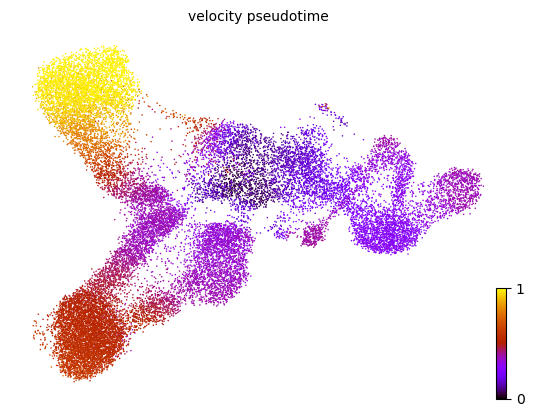

In [43]:
scv.tl.velocity_pseudotime(adata_dict['adata_gut_deterministic'])
scv.pl.scatter(adata_dict['adata_gut_deterministic'], color='velocity_pseudotime', cmap='gnuplot')

In [32]:
df = adata_dict['adata_gut_deterministic'].obs

In [37]:
df[df["leiden"]=="11"]

,cell_id,x_centroid,y_centroid,transcript_counts,total_counts,cell_area,nucleus_area,n_counts,leiden,velocity_self_transition
472,ahlnpcjp-1,4958.910156,6111.210938,131,131,62.225315,47.143127,72.230682,11,0.500543
487,ahlojklo-1,4961.220703,6477.925293,411,411,253.462040,24.745626,74.629456,11,0.573368
488,ahlokcnl-1,4949.104492,6485.441406,640,640,292.522198,32.873751,76.484406,11,0.548775
489,ahlokfha-1,4937.860840,6485.326660,361,361,192.726882,31.609376,73.470016,11,0.578376
490,ahlokjji-1,4966.185547,6499.968262,518,518,242.308446,43.891877,75.356705,11,0.545614
...,...,...,...,...,...,...,...,...,...,...
20484,kgbelkjl-1,4988.449219,6946.336426,280,280,158.362974,10.656875,70.477234,11,0.448452
20529,kgbigkjm-1,5000.434570,6897.215332,168,168,160.033756,30.570782,71.292984,11,0.606236
20533,kgbimnpb-1,5025.992676,6899.882324,180,180,71.346878,15.398282,68.609634,11,0.602040
20534,kgbionil-1,5023.135254,6888.920410,211,211,194.036413,48.046252,70.650116,11,0.628550


In [ ]:
adata_dict['adata_gut_deterministic'].obs["leiden"]

,cell_id,x_centroid,y_centroid,transcript_counts,total_counts,cell_area,nucleus_area,n_counts,leiden,velocity_self_transition
0,abjgjoaf-1,5897.172363,7599.086426,130,130,106.072035,31.338439,59.003845,1,0.281476
1,abjglddb-1,5848.748047,7602.782715,204,204,136.823442,43.214533,71.558105,1,0.352926
2,abjglejn-1,5853.075195,7612.978027,369,369,143.190474,40.640626,72.699799,1,0.393813
3,abjgnoee-1,5847.333008,7586.984863,130,130,103.633598,42.627502,63.928471,1,0.441815
4,abjgpfnc-1,5892.042480,7610.282715,277,277,249.036728,8.624844,64.056870,1,0.289363
...,...,...,...,...,...,...,...,...,...,...
24717,ocajgakd-1,5817.336914,5933.830566,315,315,173.941881,18.559219,90.108360,7,0.010112
24718,ocajhaie-1,5802.827637,5980.475586,217,217,56.219533,18.694688,77.209572,3,0.485056
24719,ocajhjmm-1,5811.329590,5982.057617,156,156,47.775314,31.519064,78.013092,3,0.456489
24720,ocajijjl-1,5793.574707,5981.429199,197,197,136.733130,36.486251,80.201706,3,0.179317


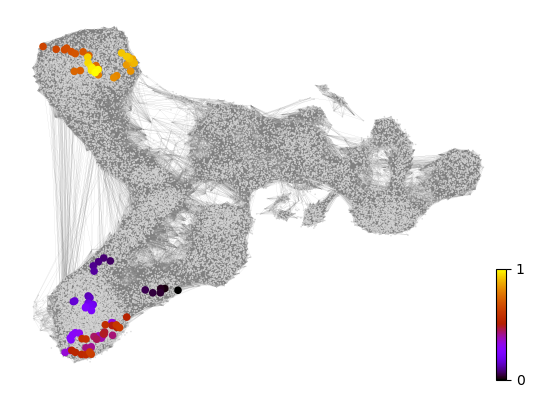

In [38]:
x, y = scv.utils.get_cell_transitions(adata_dict['adata_gut_deterministic'], basis='umap', starting_cell=20533)
ax = scv.pl.velocity_graph(adata_dict['adata_gut_deterministic'], c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata_dict['adata_gut_deterministic'], x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

In [45]:
scv.tl.velocity_pseudotime(adata_dict['adata_gut_deterministic'])

In [38]:
adata_dict['adata_gut_deterministic'].obs

,cell_id,x_centroid,y_centroid,transcript_counts,total_counts,cell_area,nucleus_area,n_counts,leiden,velocity_self_transition,root_cells,end_points,velocity_pseudotime
9287,abjgjoaf-1,5897.172363,7599.086426,130,130,106.072035,31.338439,59.003845,1,0.281476,0.004212,0.840969,0.973088
9289,abjglddb-1,5848.748047,7602.782715,204,204,136.823442,43.214533,71.558105,1,0.352926,0.000226,0.741650,0.961228
9290,abjglejn-1,5853.075195,7612.978027,369,369,143.190474,40.640626,72.699799,1,0.393813,0.000142,0.833797,0.974708
9291,abjgnoee-1,5847.333008,7586.984863,130,130,103.633598,42.627502,63.928471,1,0.441815,0.000412,0.549982,0.936073
9292,abjgpfnc-1,5892.042480,7610.282715,277,277,249.036728,8.624844,64.056870,1,0.289363,0.001767,1.000000,0.923540
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1316172,ocajgakd-1,5817.336914,5933.830566,315,315,173.941881,18.559219,90.108360,7,0.010112,0.981666,0.001159,0.113535
1316173,ocajhaie-1,5802.827637,5980.475586,217,217,56.219533,18.694688,77.209572,3,0.485056,0.000425,0.000635,0.368939
1316174,ocajhjmm-1,5811.329590,5982.057617,156,156,47.775314,31.519064,78.013092,3,0.456489,0.001383,0.000695,0.344526
1316175,ocajijjl-1,5793.574707,5981.429199,197,197,136.733130,36.486251,80.201706,3,0.179317,0.000480,0.000433,0.442745


In [46]:
# this is needed due to a current bug - bugfix is coming soon.
adata_dict['adata_gut_deterministic'].uns['neighbors']['distances'] = adata_dict['adata_gut_deterministic'].obsp['distances']
adata_dict['adata_gut_deterministic'].uns['neighbors']['connectivities'] = adata_dict['adata_gut_deterministic'].obsp['connectivities']

scv.tl.paga(adata_dict['adata_gut_deterministic'], groups='leiden')
df = scv.get_df(adata_dict['adata_gut_deterministic'], 'paga/transitions_confidence', precision=2).T
df.style.background_gradient(cmap='Blues').format('{:.2g}')

running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:15) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0,4.6,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,nan,0,0,0,0,nan,0,0,0,0,0,6.1,0,0,0
3,nan,0,0,0,0,nan,0,0,0,0,0,17,0,0,0
4,0,0,0,0,0,0,0,0,0,0,nan,0,0,0,0
5,nan,14,0,0,0,0,0,0,0,0,0,0,0,nan,0
6,nan,0,0,nan,13,0,0,0,0,1.7,0,0,0,0,0
7,0,nan,0,1.4,1.5,nan,nan,0,nan,0,nan,nan,nan,0,nan
8,nan,nan,0,0,0,0,7.8,0,0,nan,nan,0,0,0,0
9,0,0,0,0,nan,nan,0,0,0,0,0.64,0,1.3,0,0


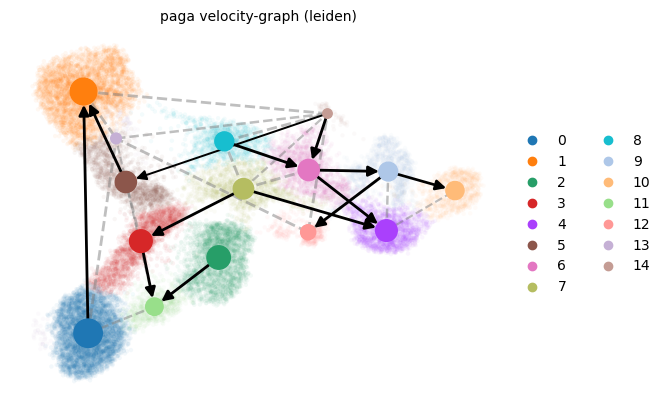

In [48]:
scv.pl.paga(adata_dict['adata_gut_deterministic'], basis='umap', size=40, alpha=.05,
            min_edge_width=0.5, node_size_scale=1.5)

In [28]:
transition_matrix = scv.utils.get_transition_matrix(adata)

In [29]:
transition_matrix

<3696x3696 sparse matrix of type '<class 'numpy.float32'>'
	with 681987 stored elements in Compressed Sparse Row format>

In [26]:
scv.tl.rank_velocity_genes(adata_dict['adata_gut_deterministic'], groupby='leiden', min_corr=.3)

df = scv.get_df(adata_dict['adata_gut_deterministic'].uns['rank_velocity_genes']['names'])
df.head(6)

ranking velocity genes
    finished (0:00:02) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,19,266,17,273,275,269,275,41,53,133,300,19,300,301,51
1,0,106,66,327,56,124,294,231,47,275,329,0,336,302,163
2,285,177,80,199,21,327,77,126,21,294,15,199,145,23,232
3,11,351,328,269,268,287,167,263,349,308,105,78,79,303,133
4,324,305,214,19,105,330,240,230,264,226,77,66,354,352,178
5,188,201,260,11,77,155,244,212,61,316,240,344,215,68,283


In [27]:
import warnings

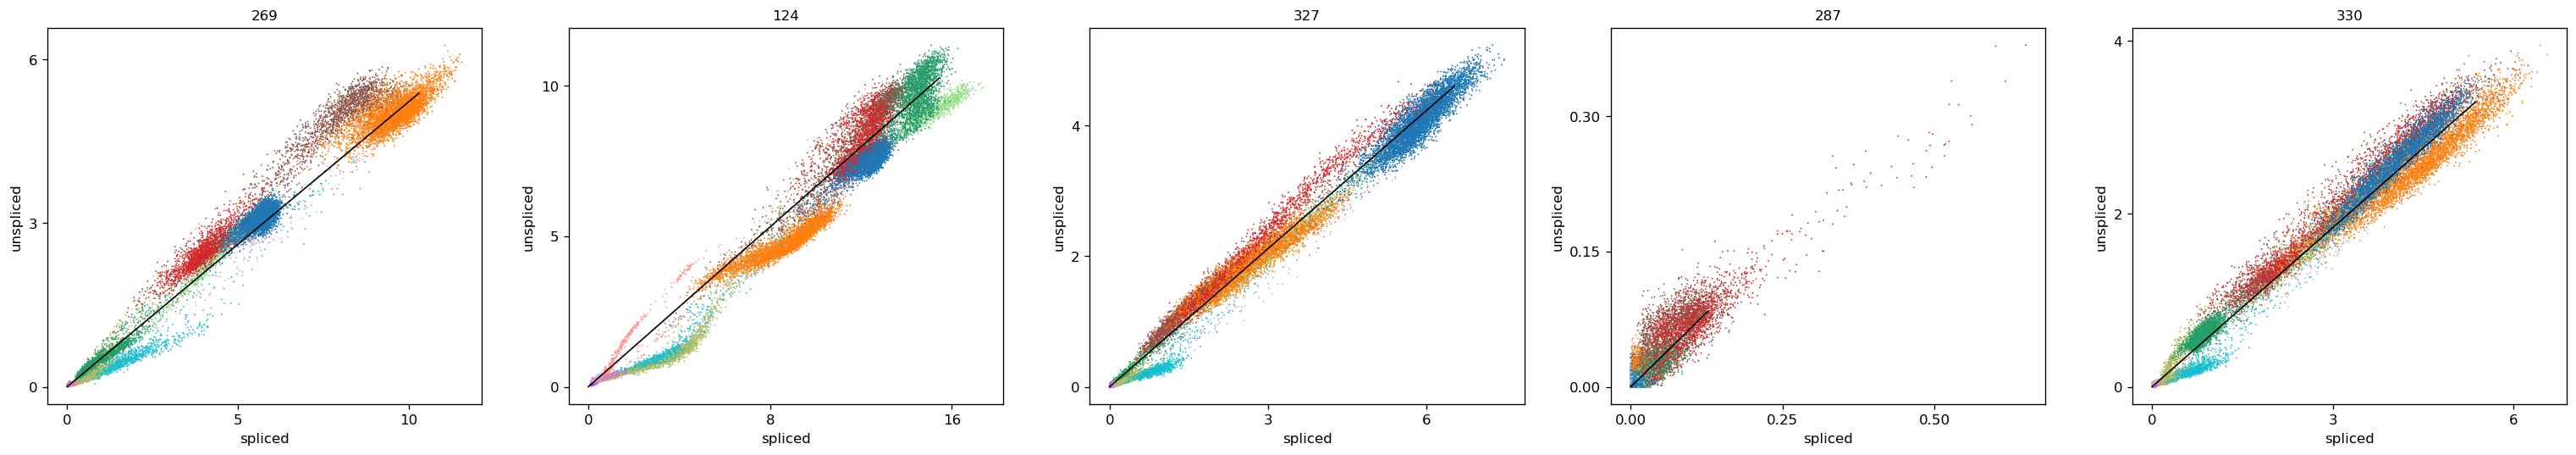

In [34]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scv.pl.scatter(adata_dict['adata_gut_deterministic'], df['5'][0:5],color="leiden",dpi=120)

## Dynamic Velocity 

computing velocity embedding
    finished (0:00:09) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


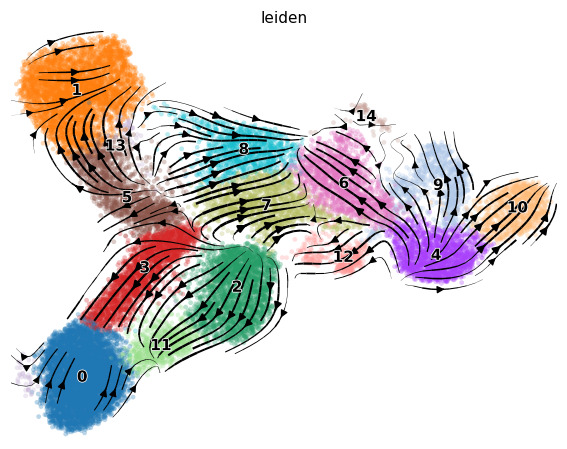

In [49]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scv.pl.velocity_embedding_stream(adata_dict['adata_gut_dynamical'], basis='umap',color="leiden", dpi=110)
    # scv.pl.velocity_embedding_stream(adata, basis='spatial',color="leiden")

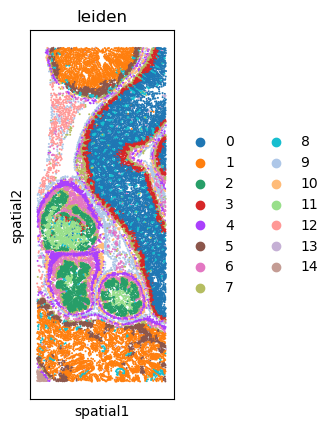

In [50]:
sc.pl.spatial(adata_dict['adata_gut_deterministic'], color="leiden", spot_size = 20)

In [75]:
adata = adata_dict['adata_gut_dynamical']

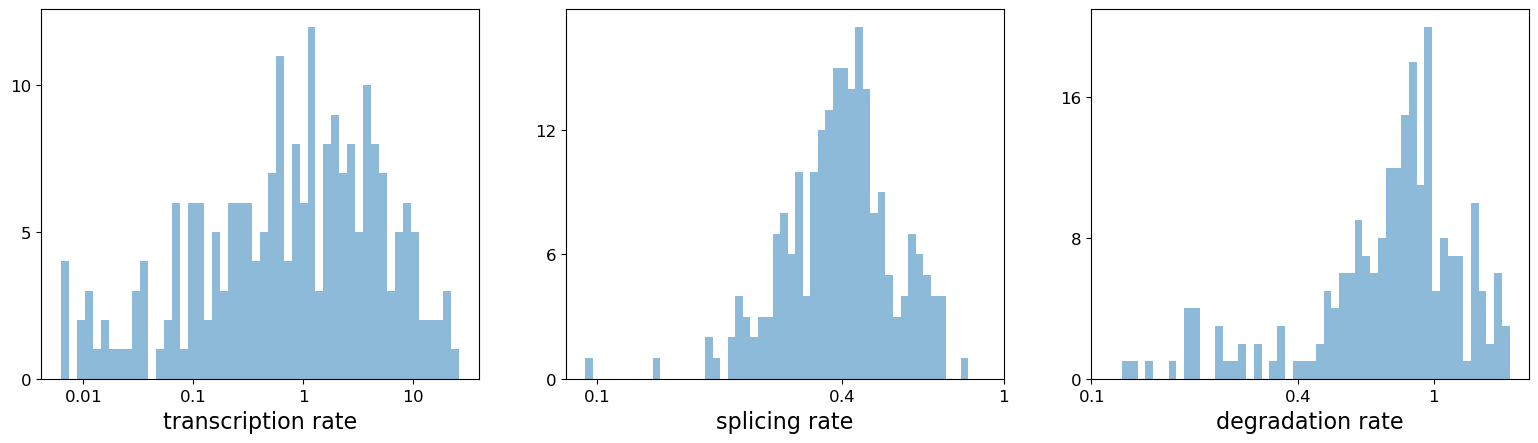

,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
0,0.64,0.12,0.41,0.54,9.77,1.97,0.11,0.05,0.29,0.0,0.0,8.94e-04,0.24,0.13,0.67,1.25
2,0.99,9.40,1.74,1.04,5.32,0.27,1.14,1.99,0.39,0.0,0.0,4.98e-01,5.10,8.69,0.30,0.95
3,0.79,0.74,0.72,0.88,4.85,0.57,0.14,0.11,0.08,0.0,0.0,4.87e-01,1.25,0.47,2.04,1.04
4,0.96,1.48,1.96,1.20,8.13,0.29,0.19,0.31,0.42,0.0,0.0,4.92e-01,0.50,1.16,0.26,0.79
5,0.87,0.27,0.20,0.66,6.34,1.99,0.31,0.07,0.25,0.0,0.0,4.46e-01,0.85,0.24,0.65,1.07


In [54]:
df = adata.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]
kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(adata, 'fit*', dropna=True).head()

In [55]:
df_fit_gut = scv.get_df(adata, 'fit*', dropna=True)

In [56]:
df_fit_gut.reset_index(inplace=True,drop=True)

In [17]:
df_fit_gut.to_csv('data/Xenium_V1_mouse_pup_outs/df_fit_gut.csv')

### latent time 

computing terminal states
    identified 8 regions of root cells and 2 regions of end points .
    finished (0:00:11) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:09) --> added 
    'latent_time', shared time (adata.obs)


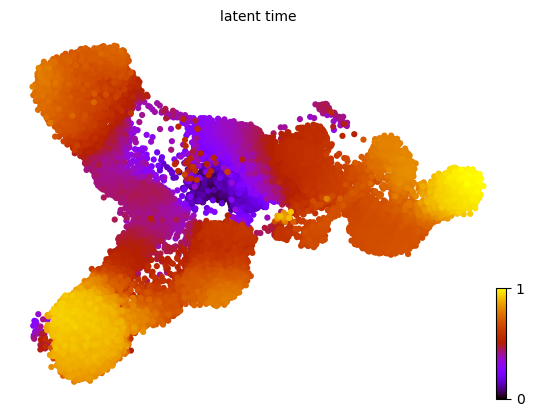

In [57]:
scv.tl.latent_time(adata)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scv.pl.scatter(adata, color='latent_time', color_map='gnuplot', size=80)

In [45]:
adata.var.set_index("gene_name",drop=True,inplace=True)

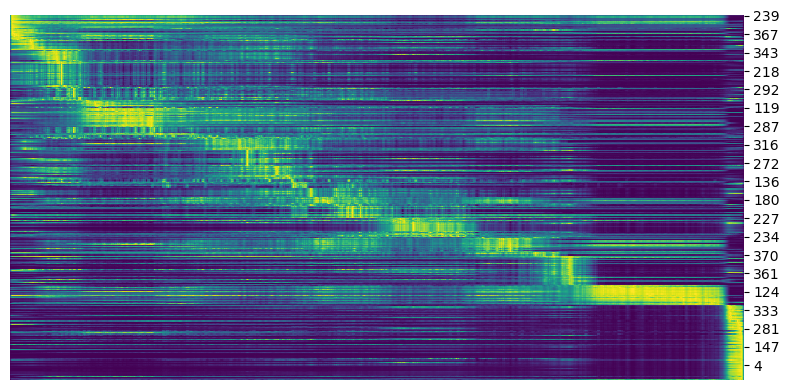

In [58]:
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index
scv.pl.heatmap(adata, var_names=top_genes, sortby='latent_time',  n_convolve=100)

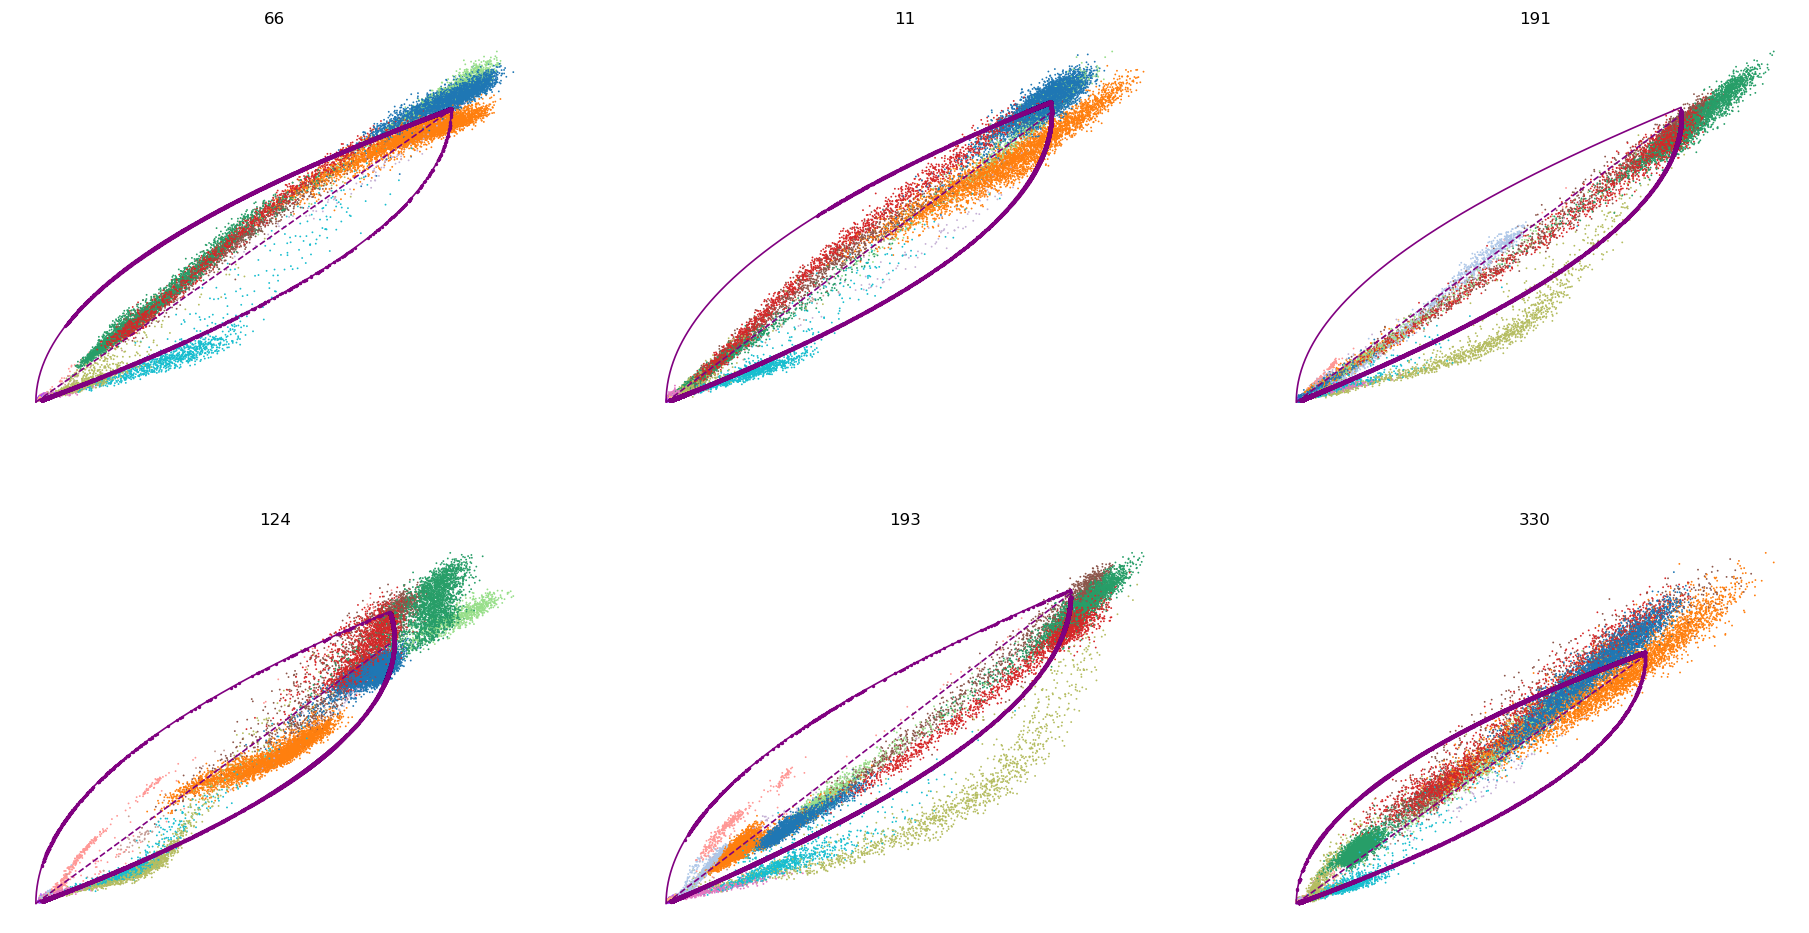

In [59]:
import warnings

top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scv.pl.scatter(adata,color="leiden", basis=top_genes[:6], ncols=3, frameon=False,dpi=120)

In [66]:
scv.tl.rank_dynamical_genes(adata, groupby='leiden')
df = scv.get_df(adata, 'rank_dynamical_genes/names')
df.head(5)

ranking genes by cluster-specific likelihoods
    finished (0:00:08) --> added 
    'rank_dynamical_genes', sorted scores by group ids (adata.uns)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Cdhr5,Cdhr5,Krt8,Krt8,Mgll,Krt19,Sdc1,Krt19,Rbp2,Isca1,Isca1,Cndp2,Krt8,Ace2,Hmgcs2
1,Epcam,Apoc2,Krt19,Krt19,Myl9,Krt8,Isca1,Stmn1,Ndrg1,Cav1,Mylk,Ace2,Epcam,Slc34a2,Krt8
2,Ace2,Cldn2,Tspan8,Epcam,Timp3,Epcam,Stmn1,Isca1,Timp3,Timp3,Timp3,Cldn2,Cldn3,Cldn2,Ace2
3,Cubn,Ace2,Cubn,Cubn,Myh11,Isca1,Myl9,Timp3,Cav1,Sdc1,Slc4a4,Tm4sf20,Anxa2,Epcam,Mylk3
4,Krt8,Cubn,Isca1,Isca1,Tagln,Anxa2,Anxa2,Mgll,Hmgcs2,Stmn1,Ndufs8,Tspan8,Hpgd,Tspan8,Tm4sf20


In [65]:
adata.var.set_index('gene_name',drop=True,inplace=True)

In [ ]:
for cluster in ['2610528A11Rik', 'Krt8', 'Mgll', 'Cndp2']:
    scv.pl.scatter(adata, df[cluster][:5], ylabel=cluster, frameon=False,color='leiden')

In [79]:
var_names = ['Cdhr5', 'Epcam', 'Cndp2', 'Krt8']
scv.tl.differential_kinetic_test(adata, var_names=var_names, groupby='leiden')

testing for differential kinetics
    finished (0:00:07) --> added 
    'fit_diff_kinetics', clusters displaying differential kinetics (adata.var)
    'fit_pvals_kinetics', p-values of differential kinetics (adata.var)

outputs model fit of gene: Krt8


In [80]:
scv.get_df(adata[:, var_names], ['fit_diff_kinetics', 'fit_pval_kinetics'], precision=2)

,fit_diff_kinetics,fit_pval_kinetics
gene_name,,
Cdhr5,"2,3,5,11",2.43e-08
Epcam,"1,11",5.38e-13
Cndp2,"0,1",2.52e-04
Krt8,7,6.67e-04


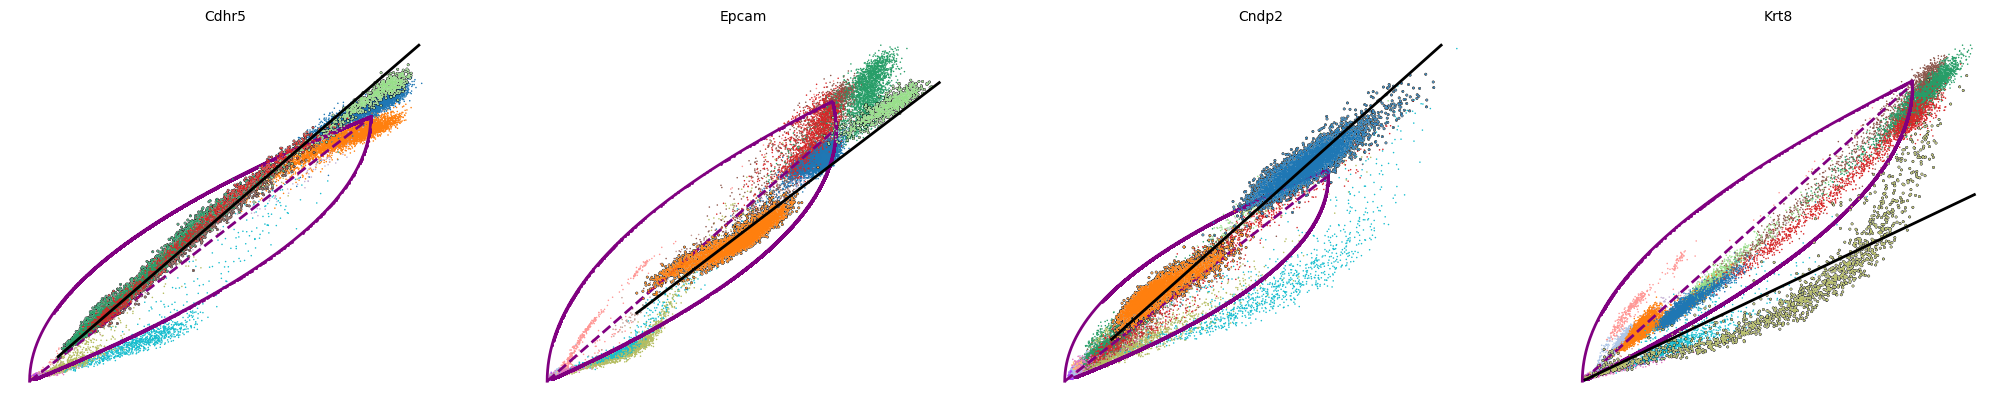

In [81]:
kwargs = dict(linewidth=2, add_linfit=True, frameon=False)
scv.pl.scatter(adata, basis=var_names, add_outline='fit_diff_kinetics', **kwargs)

In [ ]:
scv.get_df(adata[:, var_names], ['fit_diff_kinetics', 'fit_pval_kinetics'], precision=2)

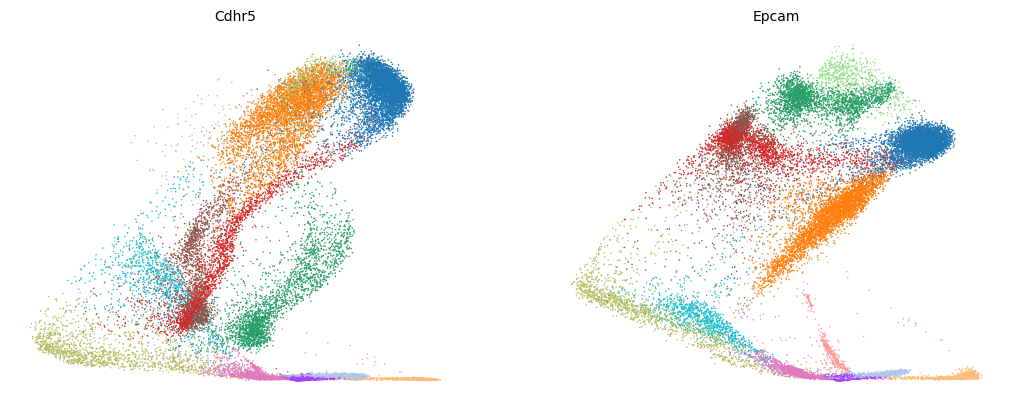

In [ ]:
var_names = ['Cdhr5', 'Epcam']
#scv.pl.scatter(adata, var_names, frameon=False)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scv.pl.scatter(adata, x='latent_time', y=var_names,color="leiden", frameon=False,add_outline=)


In [125]:
scv.tl.rank_dynamical_genes(adata, groupby='leiden')
df = scv.get_df(adata, 'rank_dynamical_genes/names')
df.head(5)

ranking genes by cluster-specific likelihoods
    finished (0:00:00) --> added 
    'rank_dynamical_genes', sorted scores by group ids (adata.uns)


/var/folders/n1/3rys77050fl0ptsh50jc4t_40000gn/T/ipykernel_1652/3630236659.py:2: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  df = scv.get_df(adata, 'rank_dynamical_genes/names')
/opt/anaconda3/envs/scvelo/lib/python3.12/site-packages/scvelo/core/_anndata.py:257: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data.obs[key])


,0,1,2,3,4,5,6
0,Cdhr5,Cdhr5,Rbp2,Epcam,Cnn1,Try10,Ace2
1,Epcam,Krt19,Hmgcs2,Ace2,Tagln,Prss3,Epcam
2,Apoc2,Krt8,Ndrg1,Cdhr5,Myh11,Dpt,Guca2b
3,Prap1,Prap1,Eng,Rbp2,Myl9,Ptprn2,Apoc2
4,Guca2b,Ace2,Tie1,Guca2b,Mylk,Tmem147,Rbp2


### Identify important genes 

In [59]:
scv.tl.rank_velocity_genes(adata, groupby='leiden', min_corr=.3)

df = scv.get_df(adata.uns['rank_velocity_genes']['names'])
df.head(6)

ranking velocity genes


c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scvelo\tools\utils.py:463: DeprecationWarning: Please import `rankdata` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import rankdata


    finished (0:00:02) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,136,136,17,47,275,273,106,244,275,329,133,70,352,246
1,0,266,328,349,308,77,327,308,299,300,359,295,301,3
2,266,351,66,215,124,26,66,363,294,91,5,43,126,145
3,84,67,67,41,363,269,11,124,133,308,241,84,302,58
4,67,0,80,149,56,124,269,21,308,124,299,91,303,255
5,338,255,239,53,105,363,199,241,240,363,244,103,3,295


In [61]:
import warnings

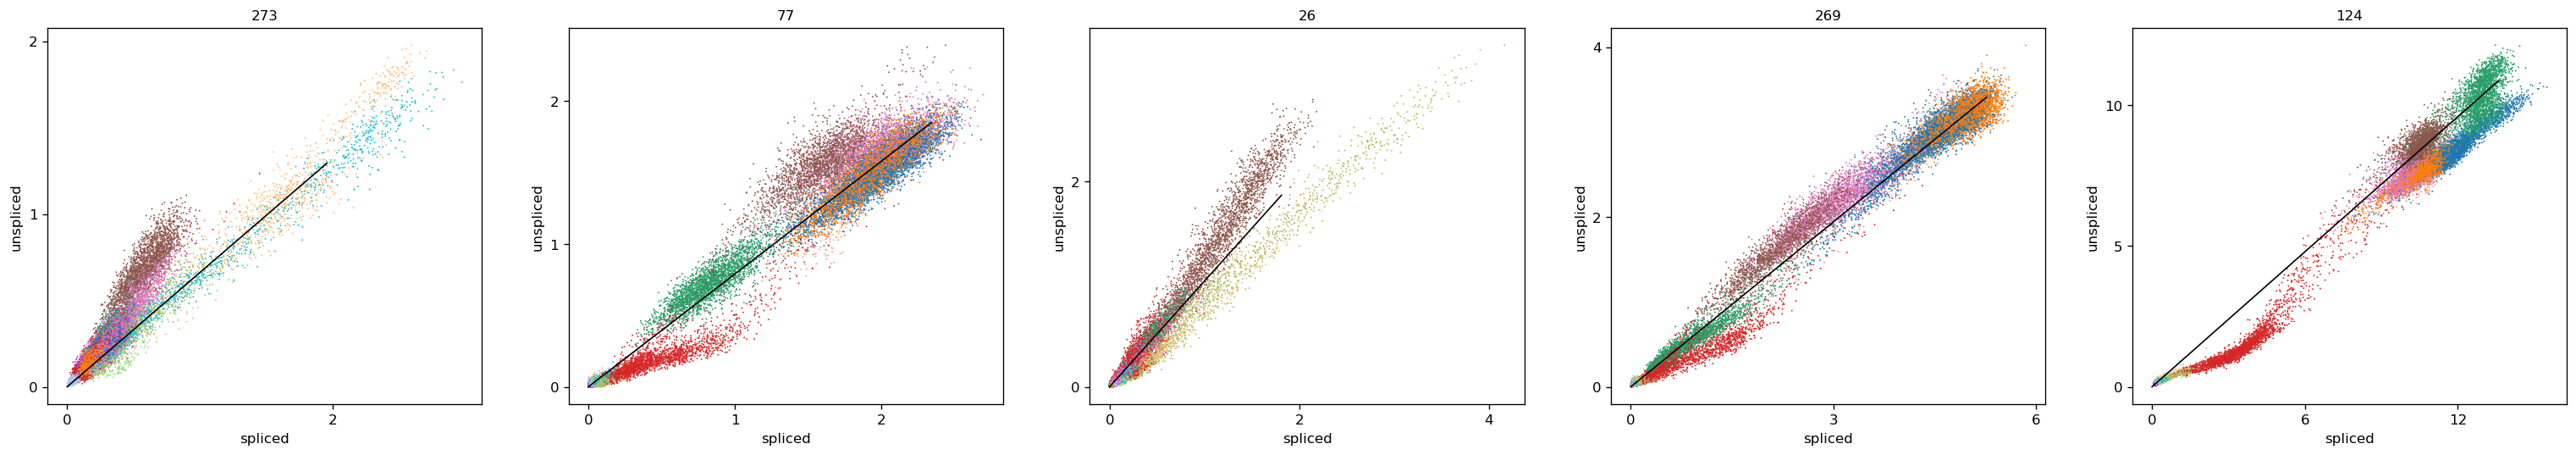

In [75]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scv.pl.scatter(adata, df['5'][0:5],color="leiden",dpi=120)

# Velocities in cycling progenitors

- cell cycle genes information is required.


In [68]:
adata.var.index

Index(['0610005C13Rik', '1110017D15Rik', '2610528A11Rik', '5330417C22Rik',
       '6330403K07Rik', 'A330076H08Rik', 'AU021092', 'Aadat', 'Abca13',
       'Abcb11',
       ...
       'Uox', 'Upk1a', 'Upk1b', 'Upk3a', 'Upk3b', 'Vsnl1', 'Vsx2', 'Vwf',
       'Wif1', 'Wnt3'],
      dtype='object', name='gene_name', length=374)

In [ ]:
scv.tl.score_genes_cell_cycle(adata)
scv.pl.scatter(adata, color_gradients=['S_score', 'G2M_score'], smooth=True, perc=[5, 95])


# Speed and Coherence

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


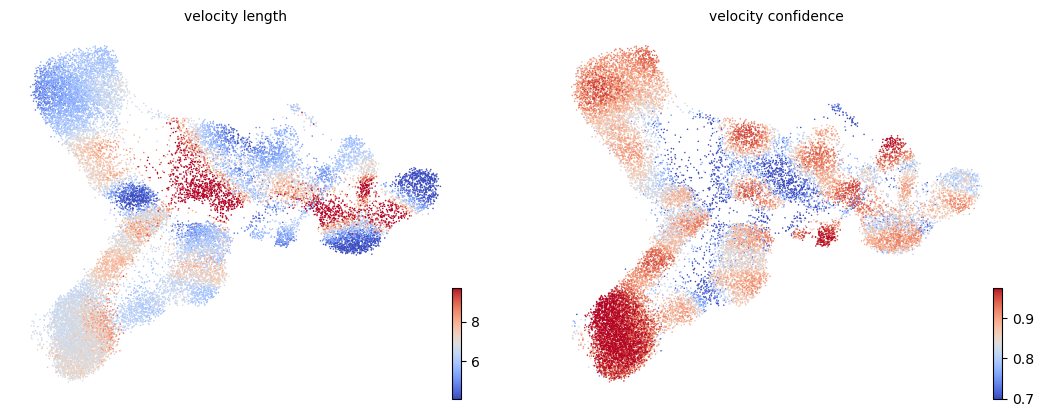

In [83]:
scv.tl.velocity_confidence(adata)
keys = 'velocity_length', 'velocity_confidence'

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scv.pl.scatter(adata, c=keys, cmap='coolwarm', perc=[5, 95])

In [84]:
adata.obs.groupby('leiden')[["velocity_length","velocity_confidence"]].mean().T

leiden,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
velocity_length,6.81,5.73,6.27,7.14,6.29,6.12,6.48,8.86,6.75,6.75,5.09,6.18,5.30,6.47,6.27
velocity_confidence,0.95,0.89,0.84,0.87,0.85,0.83,0.87,0.74,0.84,0.86,0.84,0.84,0.87,0.79,0.60


In [85]:

df = adata.obs.groupby('leiden')[["velocity_length","velocity_confidence"]].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

leiden,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
velocity_length,6.814715,5.731622,6.272674,7.139106,6.292396,6.123721,6.477759,8.858901,6.753549,6.746325,5.091176,6.184453,5.302264,6.473178,6.265303
velocity_confidence,0.946071,0.888936,0.835387,0.867829,0.853497,0.832333,0.865113,0.741386,0.844985,0.863358,0.844786,0.841163,0.874776,0.794021,0.601721


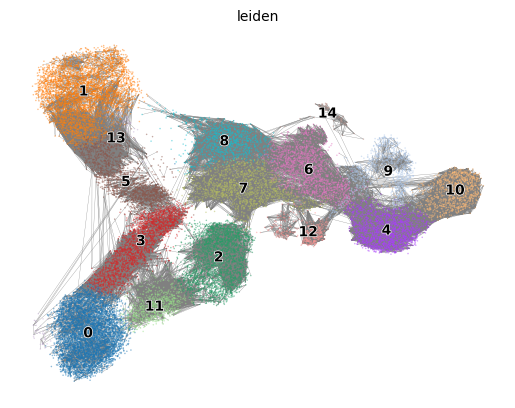

In [90]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scv.pl.velocity_graph(adata, threshold=.6,color="leiden",alpha=0.5,)

In [92]:
adata.obs.iloc[20000]

cell_id                           kfohhhld-1
x_centroid                           5113.72
y_centroid                           7004.77
transcript_counts                        136
total_counts                             136
cell_area                              39.38
nucleus_area                            9.89
n_counts                                61.8
leiden                                     2
velocity_self_transition                0.47
root_cells                              0.07
end_points                               0.0
velocity_pseudotime                     0.34
latent_time                             0.53
velocity_length                         8.14
velocity_confidence                      0.8
velocity_confidence_transition           0.3
Name: 966086, dtype: object

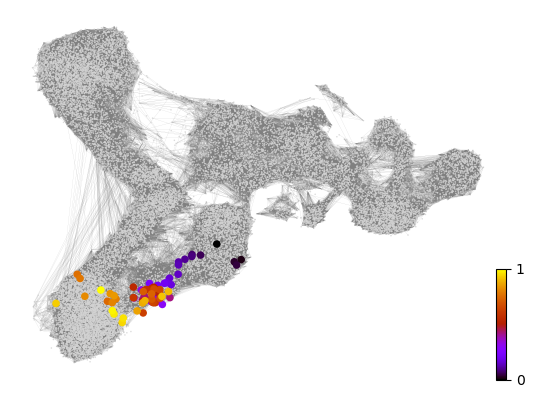

In [87]:
x, y = scv.utils.get_cell_transitions(adata, basis='umap', starting_cell=600)
ax = scv.pl.velocity_graph(adata, c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata, x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

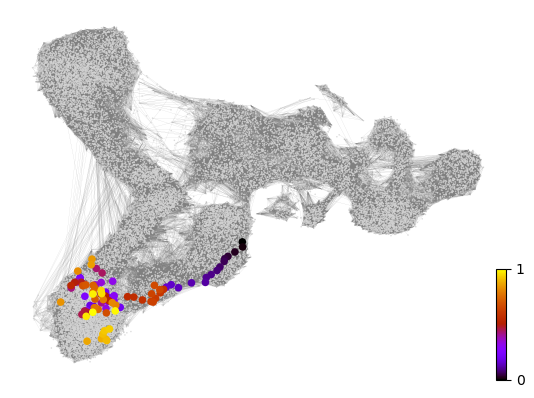

In [93]:
x, y = scv.utils.get_cell_transitions(adata, basis='umap', starting_cell=20000)
ax = scv.pl.velocity_graph(adata, c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata, x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

### Velocity Pseudotime

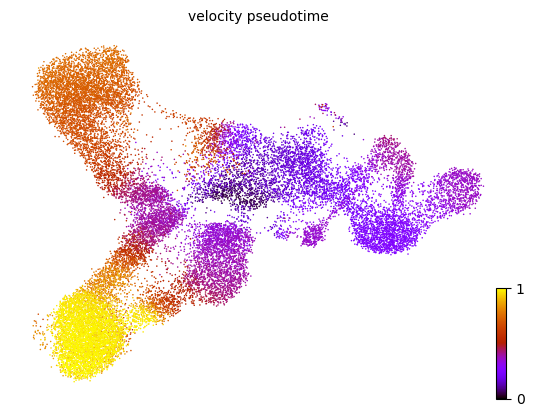

In [94]:
scv.tl.velocity_pseudotime(adata)
scv.pl.scatter(adata, color='velocity_pseudotime', cmap='gnuplot')

### PAGA velocity graph 

- scv.tl.paga() has a bug: https://github.com/theislab/scvelo/issues/1241

## Stochastic Velocity 

computing velocity embedding
    finished (0:00:08) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


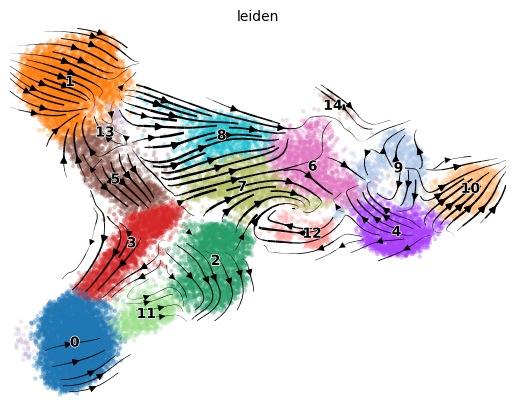

In [95]:
scv.pl.velocity_embedding_stream(adata_dict['adata_gut_stochastic'], basis='umap', color='leiden')

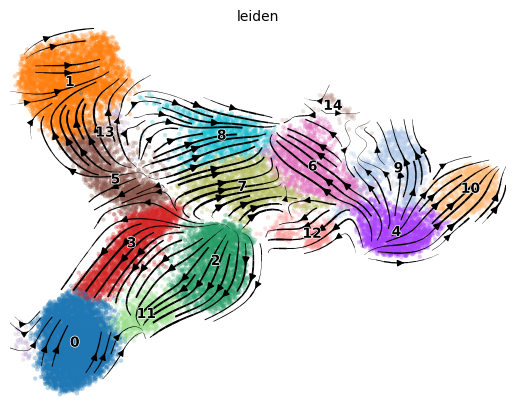

In [96]:
scv.pl.velocity_embedding_stream(adata_dict['adata_gut_dynamical'], basis='umap', color='leiden')